In [7]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

In [3]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")

### Using the whole dataset

In [47]:
subset = rainfall_events_all_df[rainfall_events_all_df['catchment_num']=='105'].copy()
subset['random_variable'] = np.random.normal(size=len(subset))
list(subset.columns)

['max_precip',
 't_global',
 't_local',
 'x_idx',
 'y_idx',
 'x_idx_global',
 'y_idx_global',
 'x_coord',
 'y_coord',
 'ens',
 'start_idx',
 'stop_idx',
 'max_precip_from_csv',
 'start_year',
 'month',
 'event_num',
 'time_mismatch',
 'rainfall_peak_day',
 'hydro_day_360',
 'day_360',
 't_local_rebased',
 'total_acc',
 'peak_position_ratio',
 'd50',
 'gini',
 'time_based_std',
 'dry_ratio',
 'max_quartile_index',
 'times',
 'values',
 'mismatch',
 '10cm_area',
 '10cm_volume',
 '30cm_area',
 '30cm_volume',
 'hc_at_peak',
 'mean_sm_2_before_event',
 'mean_sm_3_before_event',
 'mean_sm_4_before_event',
 'mean_sm_5_before_event',
 'neighbourhood_rain_total',
 'neighbourhood_rain_sum_excl_peak',
 'neighbourhood_n_cells',
 'neighbourhood_flood_10_area',
 'neighbourhood_flood_10_vol',
 'neighbourhood_flood_30_area',
 'neighbourhood_flood_30_vol',
 'threshold_rain_total_t50',
 'threshold_n_cells_t50',
 'cluster_rain_total_t50',
 'cluster_n_cells_t50',
 'threshold_flood_10_area_t50',
 'cluster_

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import statsmodels.formula.api as smf

variables = ['max_precip', 'month', 'mean_sm_2_before_event', 'fu_at_peak_new', 'fumax_at_peak',
             'lu_at_peak', 'total_acc','peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
            'random_variable', 'x_coord', 'y_coord', 'day_360']

data = subset.dropna(subset=variables + ['10cm_area']).copy()

X = data[variables]
y = data['10cm_area']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ------------------
# Linear regression
# ------------------
lr = LinearRegression()

r2_lr = cross_val_score(lr, X, y, cv=cv, scoring='r2').mean()
rmse_lr = -cross_val_score(lr, X, y, cv=cv, scoring='neg_root_mean_squared_error').mean()

# ------------------
# Random forest
# ------------------
rf = RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42)

r2_rf = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
rmse_rf = -cross_val_score(rf, X, y, cv=cv, scoring='neg_root_mean_squared_error').mean()

rf.fit(X, y)

print(f"Linear regression R²: {r2_lr:.3f}")
print(f"Random forest R²:     {r2_rf:.3f}")
print(f"Linear regression RMSE: {rmse_lr:.3f}")
print(f"Random forest RMSE:     {rmse_rf:.3f}")

Linear regression R²: 0.652
Random forest R²:     0.815
Linear regression RMSE: 0.231
Random forest RMSE:     0.168


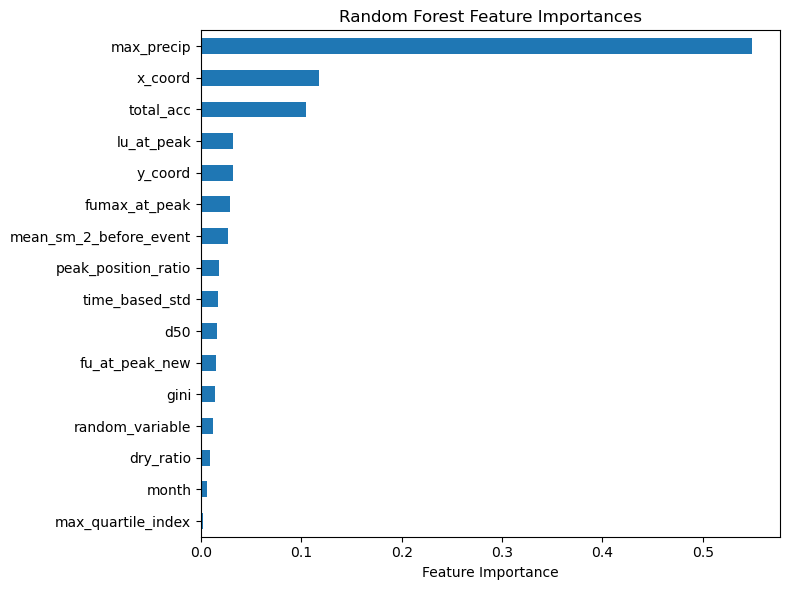

In [49]:
from sklearn.ensemble import RandomForestRegressor

importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()

In [31]:
from sklearn.inspection import permutation_importance

rf.fit(X, y)

perm = permutation_importance(rf, X, y,n_repeats=20,random_state=42,scoring='r2')

importance_rf = pd.DataFrame({'variable': X.columns,'importance': perm.importances_mean,'std': perm.importances_std
}).sort_values('importance', ascending=False)

print(importance_rf)

                  variable  importance       std
4            fumax_at_peak    0.493409  0.021007
5               lu_at_peak    0.338075  0.013852
0               max_precip    0.201461  0.010662
6                total_acc    0.194711  0.020446
2   mean_sm_2_before_event    0.040155  0.004651
9                     gini    0.017527  0.000946
3           fu_at_peak_new    0.016942  0.000585
10          time_based_std    0.012757  0.000543
8                      d50    0.011426  0.000734
7      peak_position_ratio    0.011381  0.000585
1                    month    0.011202  0.001005
11               dry_ratio    0.008259  0.000498
12      max_quartile_index    0.000673  0.000096


In [22]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, y)

importance_lr = pd.Series(
    lr_scaled.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

print(importance_lr)

(np.float64(0.7598668489043616), np.float64(0.10471595232819793))

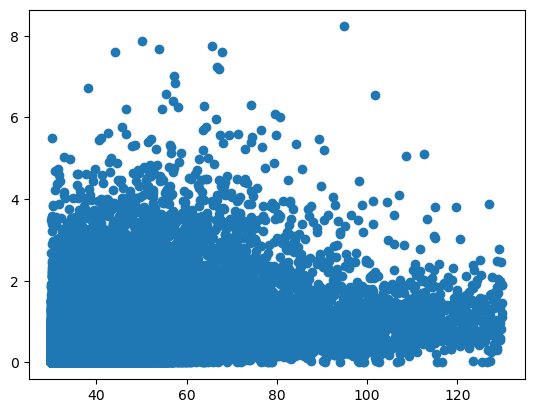

In [4]:
r2_simple, p_value = find_linear_relationship(rainfall_events_all_df, "max_precip")
plt.scatter(rainfall_events_all_df['max_precip'], rainfall_events_all_df['10cm_area'])
plt.show()

### Per region

In [82]:
def find_multiple_regress(data, variable):    
    model = smf.ols(f"Q('10cm_area') ~ max_precip + {variable}", data=data).fit()
    r2 = model.rsquared
    p_value = model.pvalues[variable]
    
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    return r2, p_value

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

def plot_r2_grid(df, suptitle, dividing_variable, xvar="max_precip", yvar="10cm_area"):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, df.iterrows()):
        
        if dividing_variable =='geo_region':
            catchment_name = row['geo_region']
        elif dividing_variable =='catchment_num':
            catchment_name = CATCHMENT_LOOKUP_DICT[row['catchment_num']]            
        
        sub = rainfall_events_all_df[rainfall_events_all_df[dividing_variable] == row[dividing_variable]
        ].dropna(subset=[xvar, yvar, "hc_at_peak"])   # same filter as the regression
        sub = sub[sub['10cm_area']>0]
        ax.scatter(sub[xvar], sub[yvar], s=20, alpha=0.8)

        # regression line for display
        if len(sub) > 1:
            m, c = np.polyfit(sub[xvar], sub[yvar], 1)
            xs = np.linspace(sub[xvar].min(), sub[xvar].max(), 50)
            ax.plot(xs, m * xs + c, color="red", lw=1.5)
            
        ax.set_title(f"{catchment_name} \n (R² = {row['r2_simple']:.2f}, p = {row['p_simple']}, n = {len(sub)}"
                     f"\n With FUmax : R² = {row['r2_fumax']:.2f}, p = {row['p_fumax']}, n = {len(sub)}  "
                     f"\n With FU : R² = {row['r2_fu']:.2f}, p = {row['p_fu']}, n = {len(sub)})",
                     fontsize=12)
        ax.set_xlabel(xvar)
        ax.set_ylabel(yvar)
        ax.set_xlabel(xvar)
        ax.set_ylabel(yvar)

    for ax in axes[len(df):]:      # hide any unused panels
        ax.set_visible(False)

    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    return fig

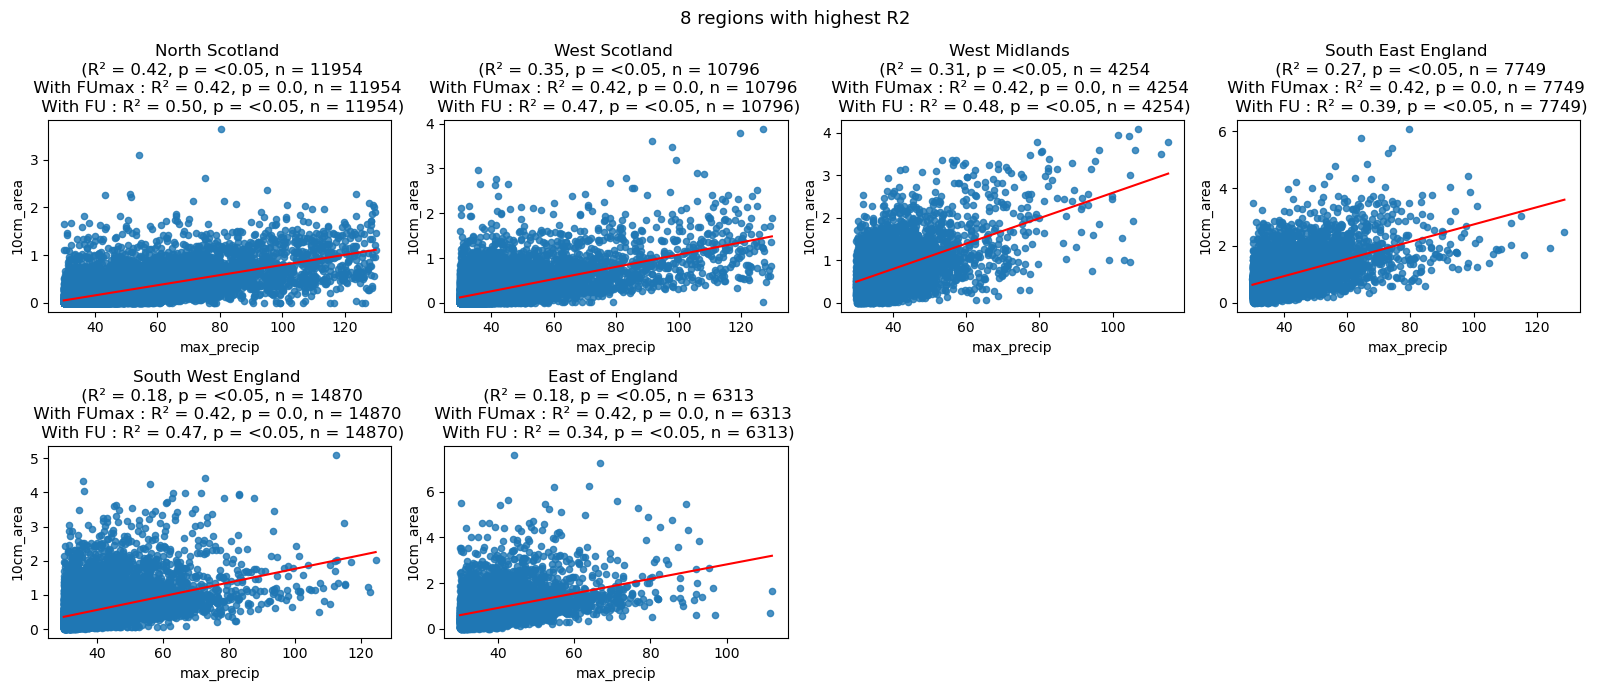

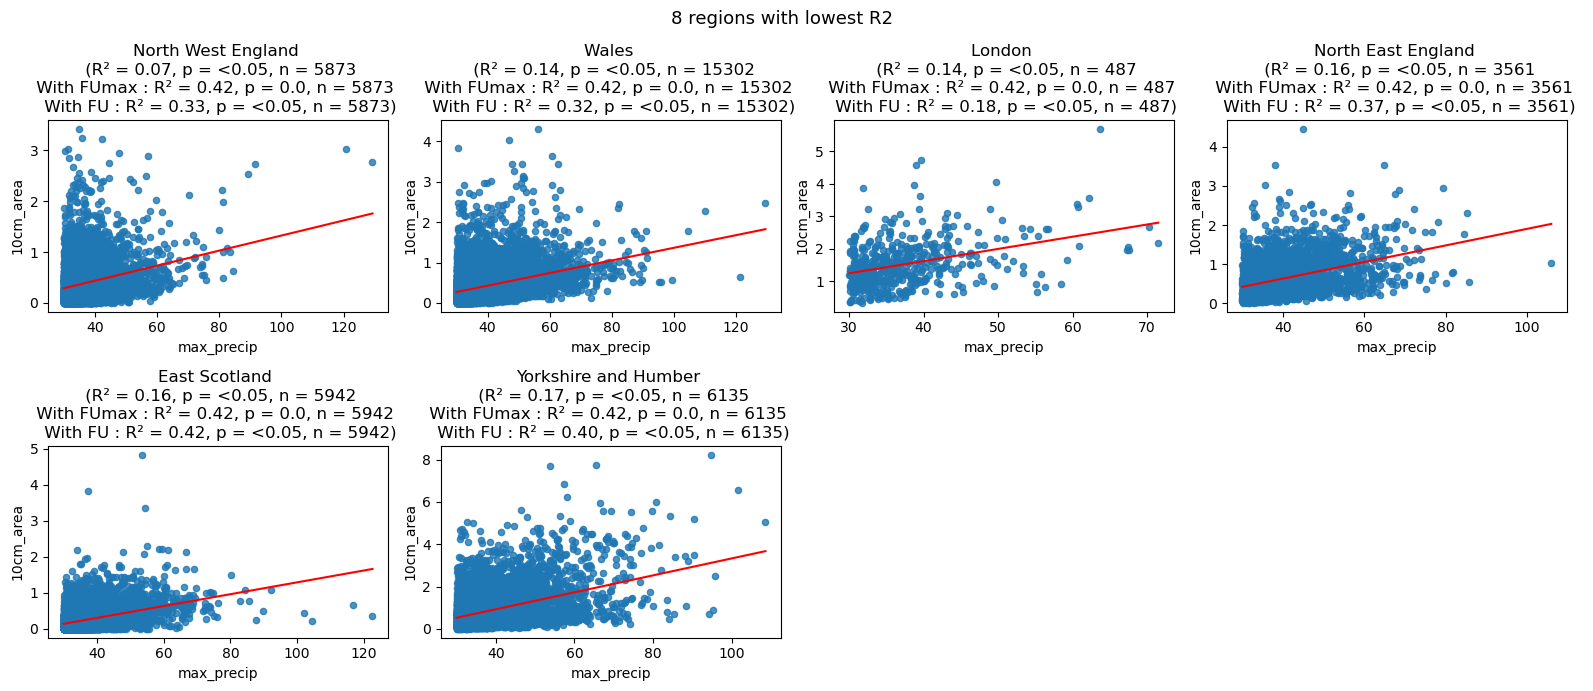

In [115]:
results = []

for region in np.unique(rainfall_events_all_df["geo_region"]):

    subset = rainfall_events_all_df[rainfall_events_all_df["geo_region"] == region].dropna(
        subset=["max_precip", "10cm_area", "hc_at_peak"])

    subset = subset[subset["10cm_area"] > 0]

    # Simple: flood area ~ rainfall intensity
    r2_simple, p_simple = find_linear_relationship(subset, "max_precip")

    # Multiple: flood area ~ rainfall intensity + fu_at_peak
    r2_fu, p_fu = find_multiple_regress (subset, "fu_at_peak_old")
    r2_fumax, p_fumax = find_multiple_regress (subset, "fumax_at_peak")

    results.append({"geo_region": region,"r2_simple": r2_simple, "p_simple": p_simple,
        "r2_fu": r2_fu,"p_fu": p_fu,"r2_fumax": model_fumax.rsquared, "p_fumax": model_fumax.pvalues["fumax_at_peak"]})

stats = pd.DataFrame(results)

top8 = stats.nlargest(6, "r2_simple")
bottom8 = stats.nsmallest(6, "r2_simple")

plot_r2_grid(top8, "8 regions with highest R2", "geo_region")
plt.show()
plot_r2_grid(bottom8, "8 regions with lowest R2", "geo_region")
plt.show()

Text(0, 0.5, 'Num catchments')

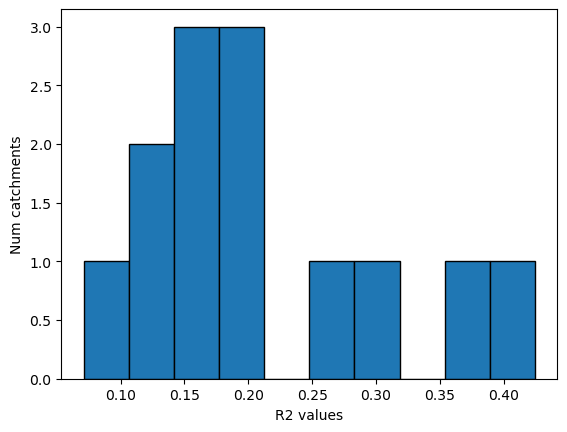

In [6]:
plt.hist(stats['r2'], edgecolor='black')
plt.xlabel('R2 values')
plt.ylabel("Num catchments")

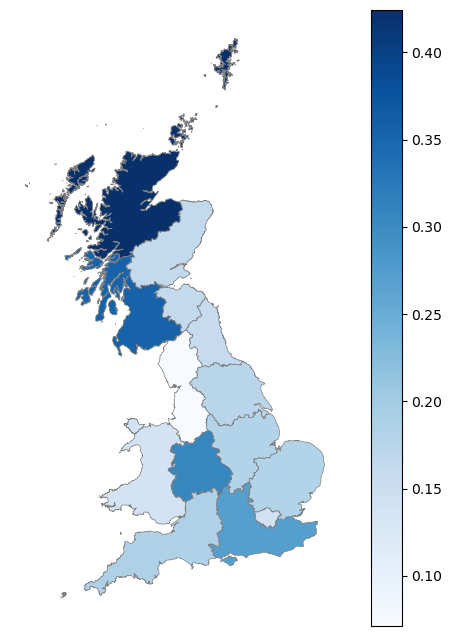

In [7]:
temp = pd.DataFrame({'geo_region': regions, 'r2_value': r2_vals})
regions_df = regions_df.merge(temp, on='geo_region')

fig, ax = plt.subplots(figsize=(8, 8))

regions_df.plot(ax=ax,column='r2_value',cmap='Blues',edgecolor='grey',linewidth=0.5,legend=True)

ax.set_axis_off()

### Per catchment

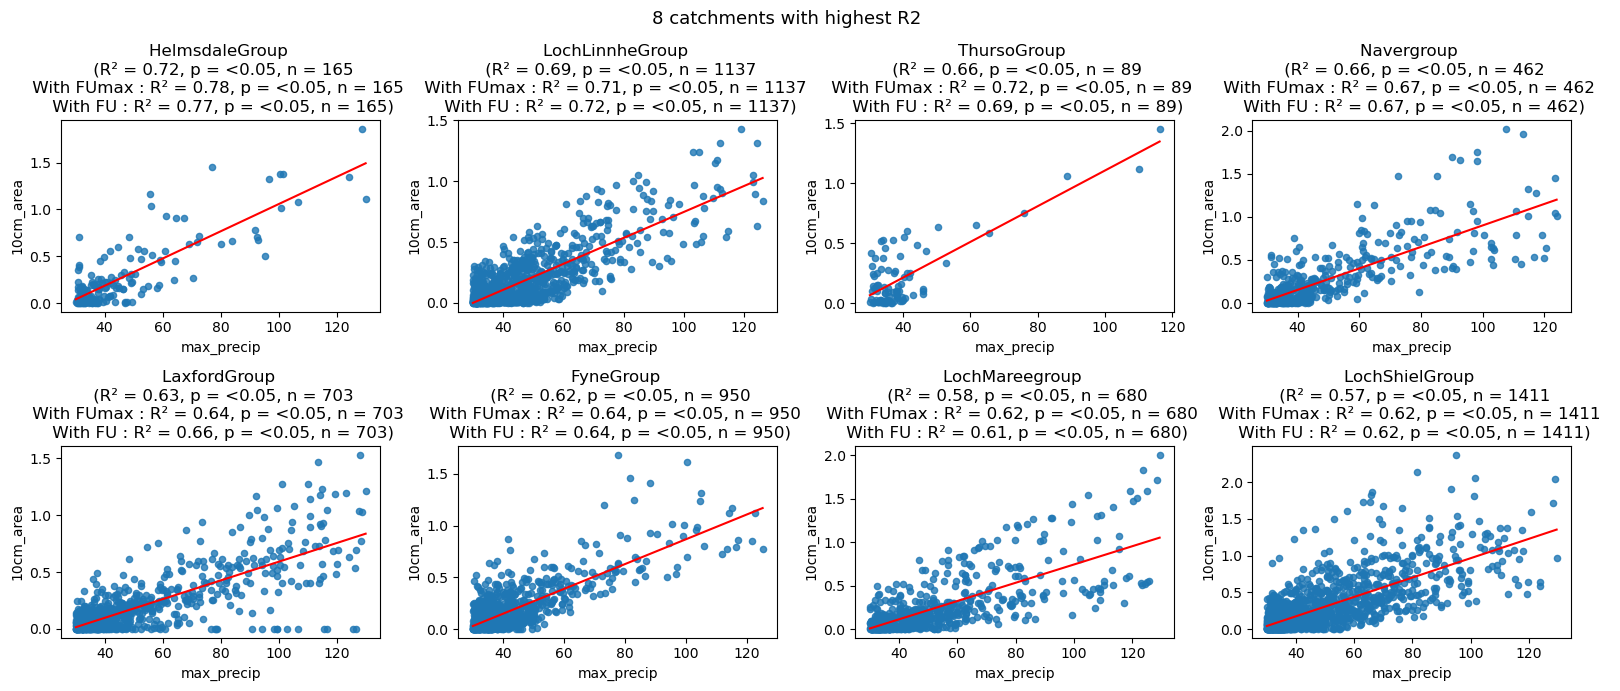

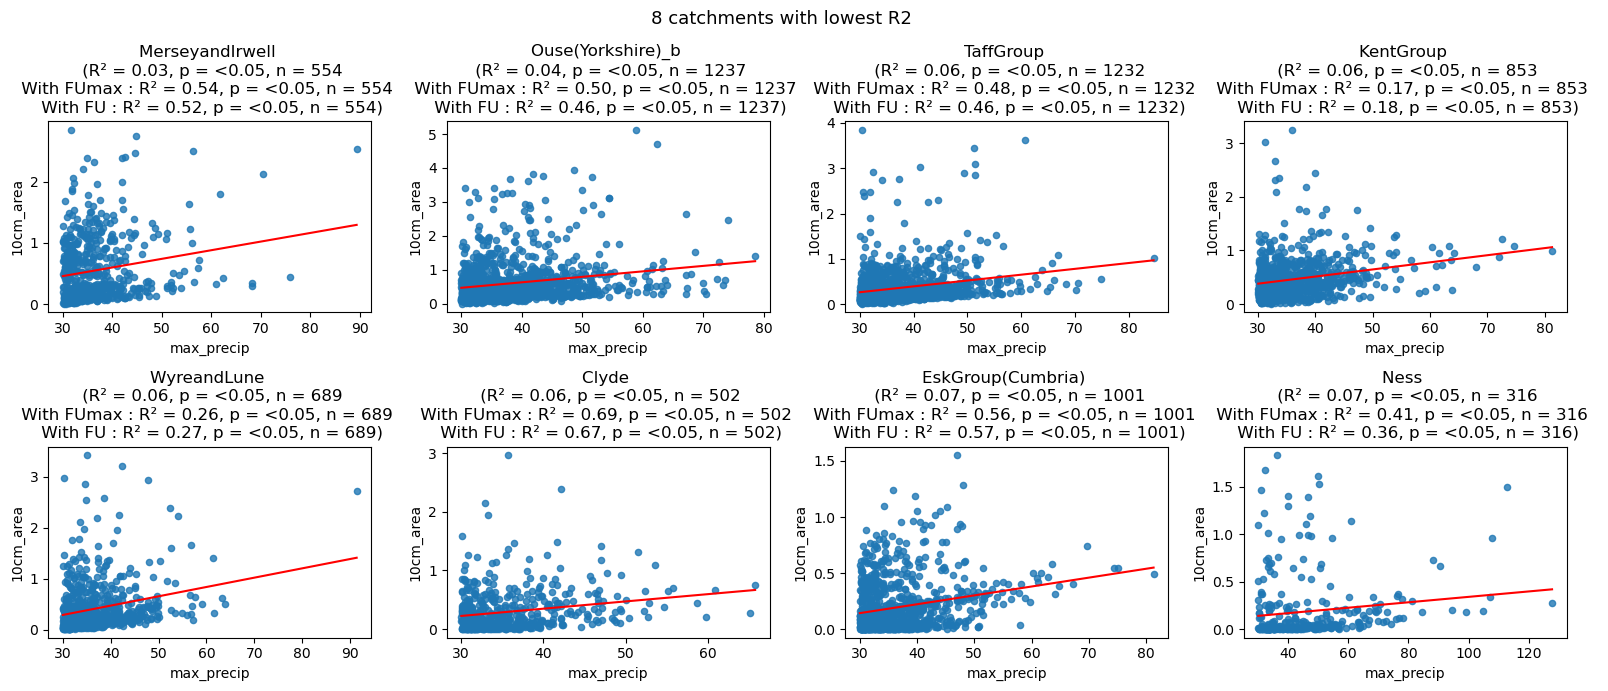

In [117]:
results = []

for catchment_num in np.unique(rainfall_events_all_df["catchment_num"]):

    subset = rainfall_events_all_df[rainfall_events_all_df["catchment_num"] == catchment_num].dropna(
        subset=["max_precip", "10cm_area", "hc_at_peak"])

    # subset = subset[subset["10cm_area"] > 0]

    # Simple: flood area ~ rainfall intensity
    r2_simple, p_simple = find_linear_relationship(subset, "max_precip")

    # Multiple: flood area ~ rainfall intensity + fu_at_peak
    r2_fu, p_fu = find_multiple_regress (subset, "fu_at_peak_old")
    r2_fumax, p_fumax = find_multiple_regress (subset, "fumax_at_peak")

    results.append({"catchment_num": catchment_num,"r2_simple": r2_simple, "p_simple": p_simple,
        "r2_fu": r2_fu,"p_fu": p_fu,"r2_fumax": r2_fumax, "p_fumax": p_fumax})

stats = pd.DataFrame(results)

stats["r2_simple"] = pd.to_numeric(stats["r2_simple"], errors="coerce")
stats = stats.dropna(subset=["r2_simple"])

top8 = stats.nlargest(8, "r2_simple")
bottom8 = stats.nsmallest(8, "r2_simple")

plot_r2_grid(top8, "8 catchments with highest R2", "catchment_num")
plt.show()
plot_r2_grid(bottom8, "8 catchments with lowest R2", "catchment_num")
plt.show()

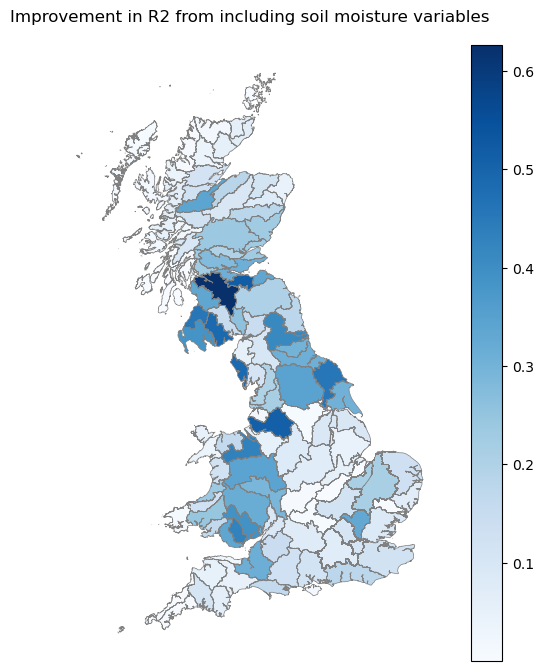

In [125]:
temp = pd.DataFrame({'HA_NUM': catchment_nums, 'r2_value': stats['diff_r2']})
temp = CATCHMENTS.merge(temp, on='HA_NUM')

fig, ax = plt.subplots(figsize=(8, 8))

temp.plot(ax=ax,column="r2_value",cmap="Blues",edgecolor="grey",linewidth=0.5,legend=True, label='Difference in R2')
ax.set_axis_off()
ax.set_title("Improvement in R2 from including soil moisture variables");

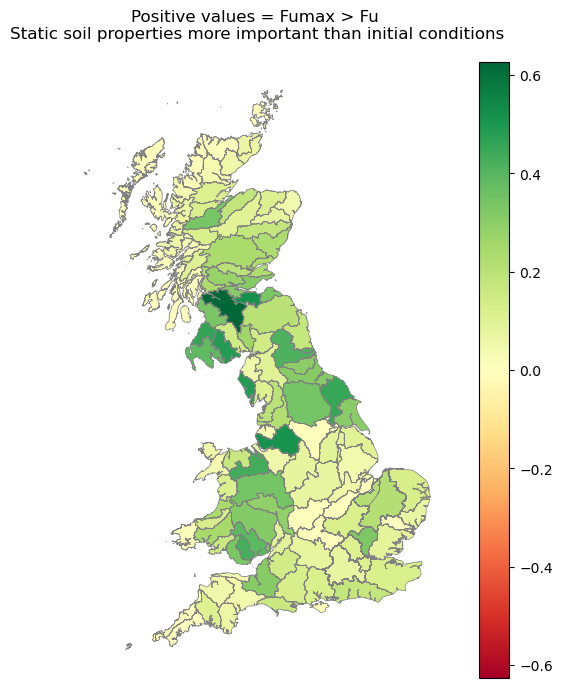

In [121]:
stats['diff_r2'] = stats['r2_fumax'] -  stats['r2_simple']
stats['diff_r2_fumax_fu'] = stats['r2_fumax'] -  stats['r2_fu']
temp = pd.DataFrame({'HA_NUM': catchment_nums, 'r2_value': stats['diff_r2_fumax_fu']})
temp = CATCHMENTS.merge(temp, on='HA_NUM')

max_abs = np.nanmax(np.abs(temp["r2_value"]))

fig, ax = plt.subplots(figsize=(8, 8))

temp.plot(ax=ax,column="r2_value",cmap="RdYlGn",edgecolor="grey",linewidth=0.5,legend=True,vmin=-max_abs,vmax=max_abs,
         label='Difference in R2')

ax.set_axis_off()
ax.set_title("Positive values = Fumax > Fu \nStatic soil properties more important than initial conditions");

Text(0, 0.5, 'Num catchments')

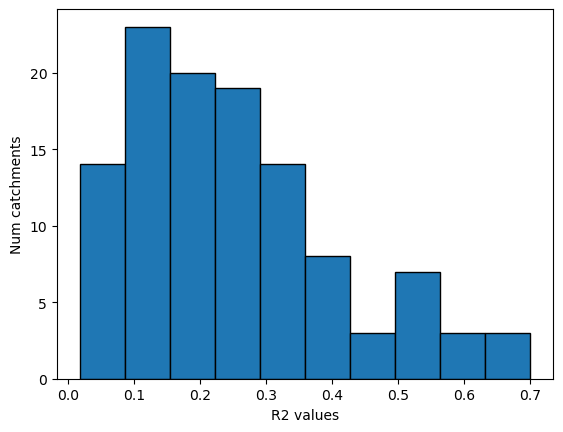

In [9]:
plt.hist(stats['r2'], edgecolor='black')
plt.xlabel('R2 values')
plt.ylabel("Num catchments")

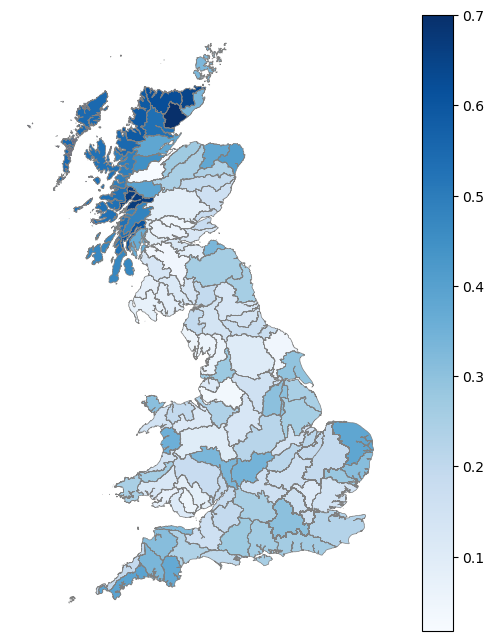

In [10]:
temp = pd.DataFrame({'HA_NUM': catchment_nums, 'r2_value': r2_vals})
CATCHMENTS = CATCHMENTS.merge(temp, on='HA_NUM')

fig, ax = plt.subplots(figsize=(8, 8))

CATCHMENTS.plot(ax=ax,column='r2_value',cmap='Blues',edgecolor='grey',linewidth=0.5,legend=True)

ax.set_axis_off()

### Per individual pixel

In [11]:
cols = ["x_idx_global", "y_idx_global"]
rainfall_events_all_df["peak_cell_id"] = rainfall_events_all_df.groupby(cols, sort=False).ngroup()

168 pixels with >20 events


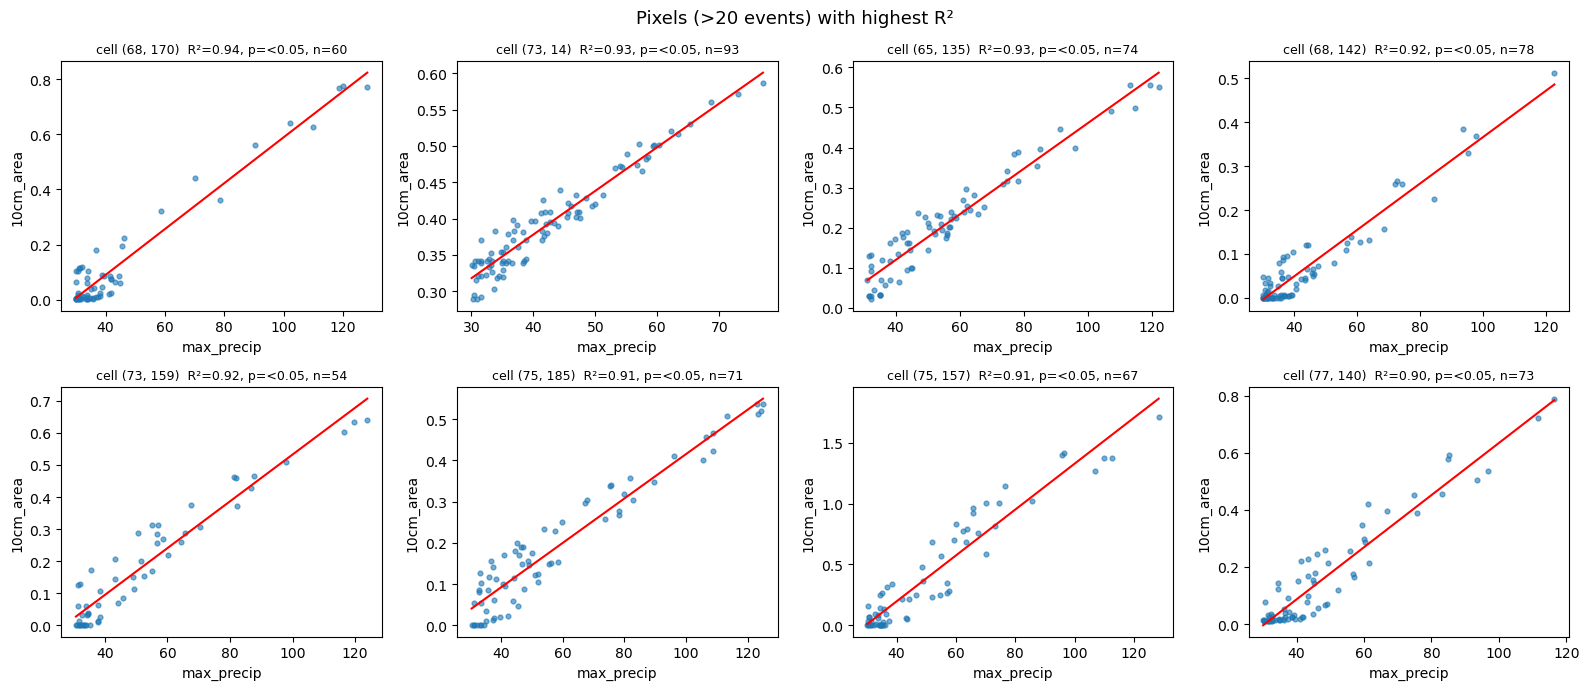

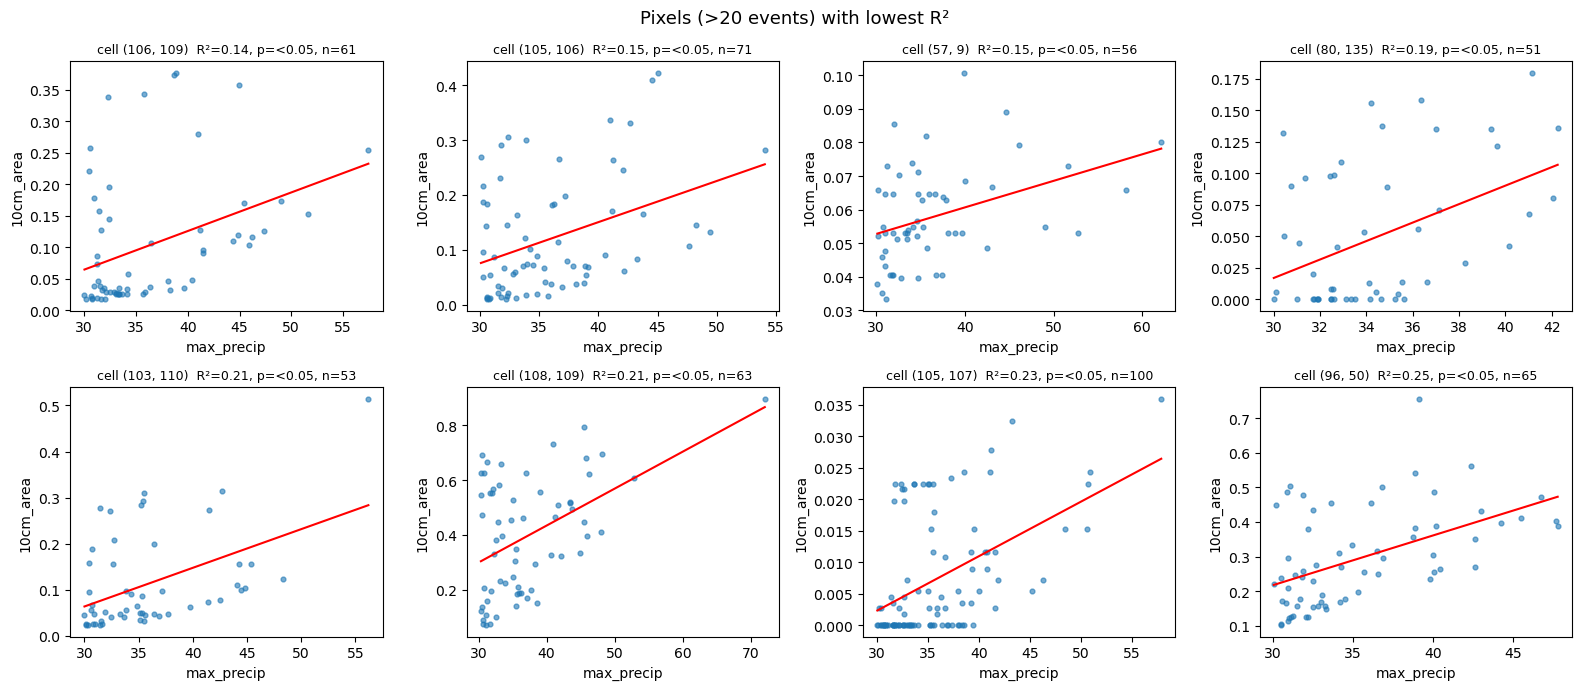

In [38]:
xvar, yvar = "max_precip", "10cm_area"

# Apply the same NaN filter the regression uses, *before* counting,
# so ">20 events" means >20 usable events
clean = rainfall_events_all_df.dropna(subset=[xvar, yvar, "hc_at_peak"])
clean = clean[clean["peak_cell_id"] >= 0]      # ngroup gives -1 for NaN indices

counts = clean["peak_cell_id"].value_counts()
busy_ids = counts[counts > 50].index
print(f"{len(busy_ids)} pixels with >20 events")

# R² and p for each busy pixel
rows = []
for pid, sub in clean[clean["peak_cell_id"].isin(busy_ids)].groupby("peak_cell_id"):
    r2, p = find_linear_relationship(sub, xvar)
    rows.append({"peak_cell_id": pid, "r2": r2, "p": p, "n": len(sub),
                 "x_idx_global": sub["x_idx_global"].iloc[0],
                 "y_idx_global": sub["y_idx_global"].iloc[0],
                "x_coord": sub["x_coord"].iloc[0],
                "y_coord": sub["y_coord"].iloc[0],})

pix_stats = pd.DataFrame(rows)
pix_stats[["r2"]] = pix_stats[["r2"]].apply(pd.to_numeric, errors="coerce")
pix_stats = pix_stats.dropna(subset=["r2"])

top8 = pix_stats.nlargest(8, "r2")
bottom8 = pix_stats.nsmallest(8, "r2")

def plot_pixel_grid(stats_sub, suptitle):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()
    for ax, (_, row) in zip(axes, stats_sub.iterrows()):
        sub = clean[clean["peak_cell_id"] == row["peak_cell_id"]]
        ax.scatter(sub[xvar], sub[yvar], s=12, alpha=0.6)
        m, c = np.polyfit(sub[xvar], sub[yvar], 1)
        xs = np.linspace(sub[xvar].min(), sub[xvar].max(), 50)
        ax.plot(xs, m * xs + c, color="red", lw=1.5)
        ax.set_title(f"cell ({int(row['x_idx_global'])}, {int(row['y_idx_global'])})  "
                     f"R²={row['r2']:.2f}, p={row['p']}, n={int(row['n'])}", fontsize=9)
        ax.set_xlabel(xvar); ax.set_ylabel(yvar)
    for ax in axes[len(stats_sub):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    return fig

plot_pixel_grid(top8, "Pixels (>20 events) with highest R²"); plt.show()
plot_pixel_grid(bottom8, "Pixels (>20 events) with lowest R²"); plt.show()

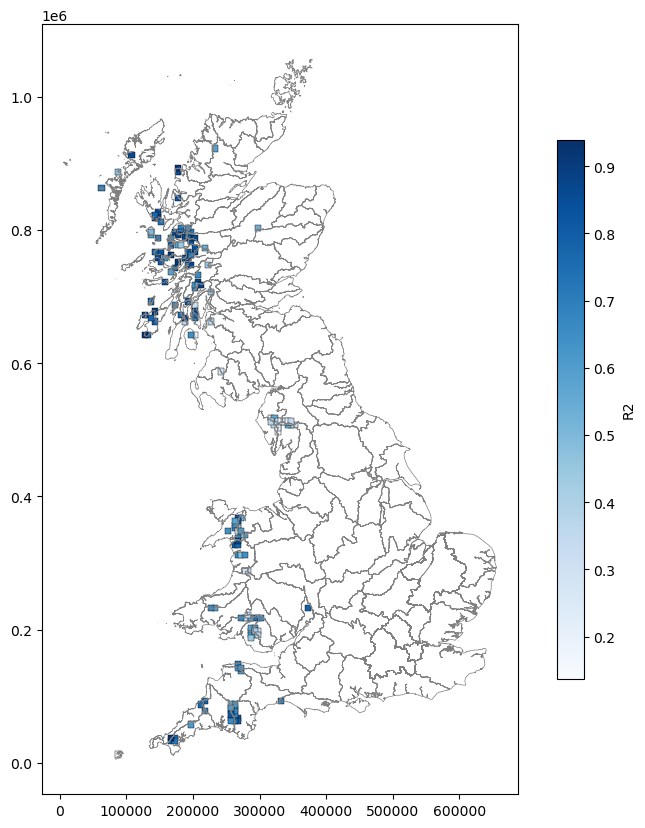

In [39]:
fig, ax = plt.subplots(figsize=(10,10))    
CATCHMENTS.boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
sc = ax.scatter(pix_stats["x_coord"], pix_stats["y_coord"], c=pix_stats['r2'], cmap='Blues',
                s=20, marker="s", edgecolor="k", linewidth=0.3)
fig.colorbar(sc, ax=ax, shrink=0.7, label='R2')
ax.set_aspect("equal")

Text(0, 0.5, 'Num pixels')

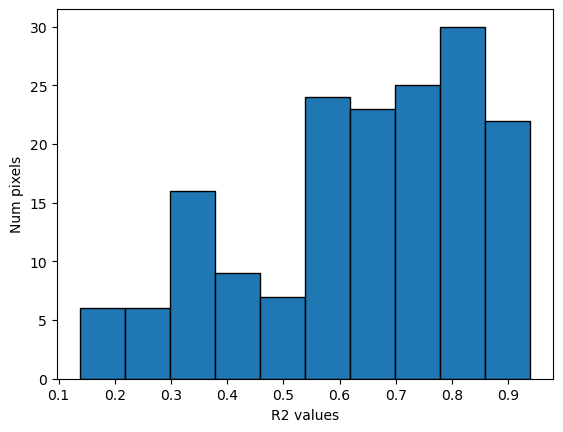

In [13]:
plt.hist(pix_stats['r2'], edgecolor='black')
plt.xlabel('R2 values')
plt.ylabel("Num pixels")

### Closer look at pixels with repeated 0 flood values

<Axes: >

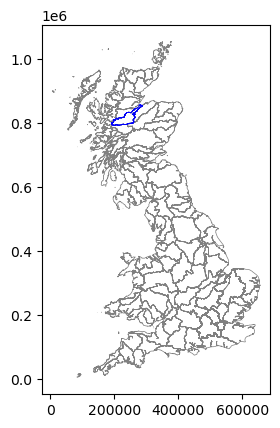

In [14]:
cols = ["x_idx_global", "y_idx_global"]
yvar, xvar = "10cm_area", "max_precip"

df = rainfall_events_all_df.copy()
df["peak_cell_id"] = df.groupby(cols, sort=False).ngroup()
df = df[df["peak_cell_id"] >= 0]                       # drop rows with NaN indices

df["is_zero"] = df[yvar] == 0                          # NaN areas count as False

pix = df.groupby("peak_cell_id").agg(n_events=("is_zero", "size"),n_zero=("is_zero", "sum"),)
pix["frac_zero"] = pix["n_zero"] / pix["n_events"]

# rank by number of zeros
top_ids = pix.sort_values("n_zero", ascending=False).index[:30]

# check which catchment has the most 0s
sub = df[df["peak_cell_id"] == 7390]
np.unique(sub['catchment_num'])

catchment96 = CATCHMENTS[CATCHMENTS['HA_NUM']=="6"]
fig, ax = plt.subplots()
CATCHMENTS.boundary.plot(ax=ax, color = None, edgecolor="grey", linewidth=0.5)
catchment96.boundary.plot(ax=ax, color = 'blue', edgecolor="grey", linewidth=0.5)

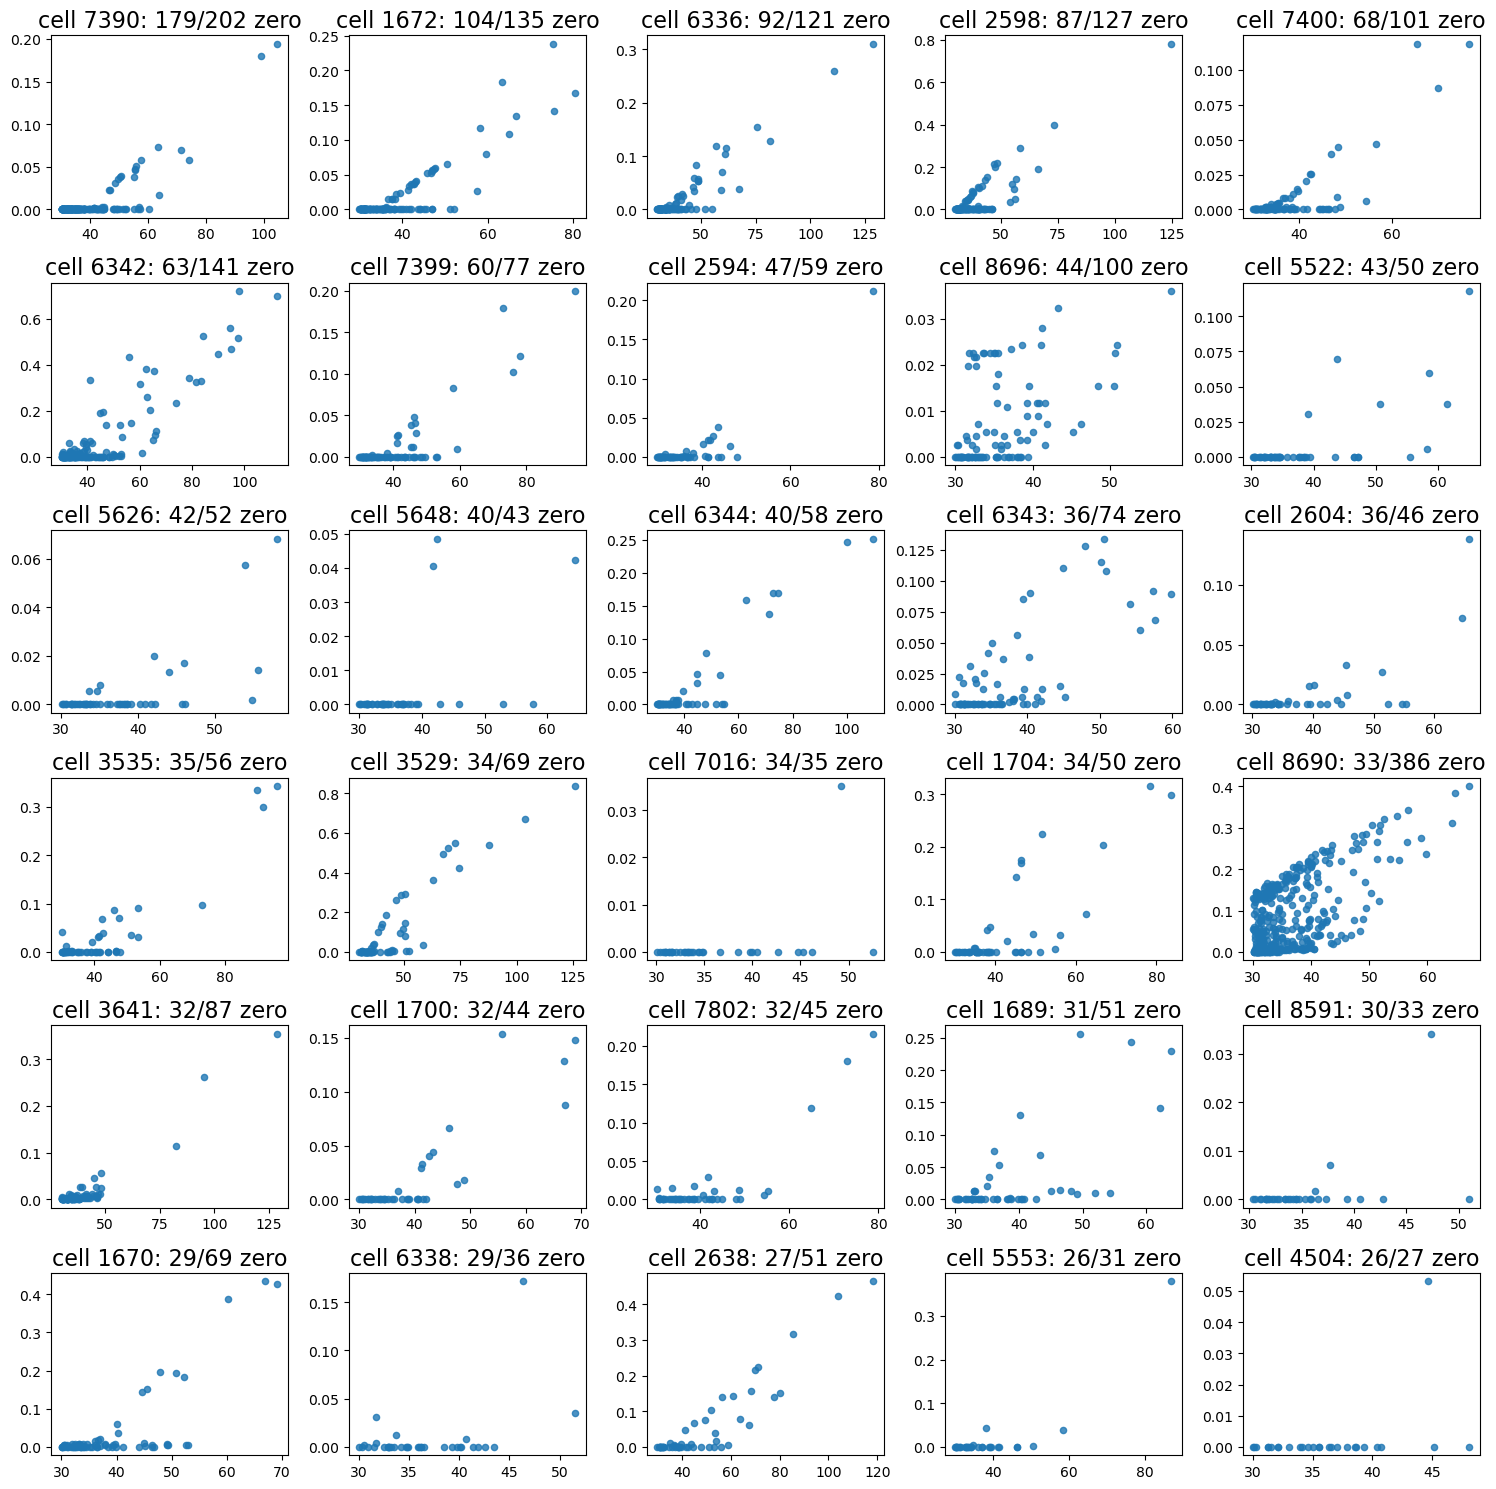

In [15]:
fig, axs = plt.subplots(ncols=5, nrows=6, figsize=(15, 15))
axs = axs.flatten()

for ax, pid in zip(axs, top_ids):
    sub = df[df["peak_cell_id"] == pid]
    ax.scatter(sub[xvar], sub[yvar], s=20, alpha=0.8)
    ax.set_title(f"cell {pid}: {int(pix.loc[pid, 'n_zero'])}/{int(pix.loc[pid, 'n_events'])} zero",
                 fontsize=16)

for ax in axs[len(top_ids):]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

In [16]:
# zeros = df[df['is_zero']==True]
# zeros_6 = zeros[zeros['catchment_num']=='6']
# zeros_6[['catchment_num', 'ens', 'event_num', 'start_year', 'max_precip', '10cm_area']][:20]

In [17]:
# df[df['is_zero']==True][['catchment_num', 'ens', 'event_num', 'start_year', 'max_precip', '10cm_area']][:100]

In [18]:
# cands = ["hc_at_peak", "max_precip"]   # add: saturation at peak, fu_at_peak, lu_at_peak,
#                                        # urban/waterbody proportion, event duration/volume...
# print(wet.groupby("is_zero")[cands].describe().T)

# # HC vs frac zero, one dot per cell
# ax = cell.plot.scatter("hc", "frac_zero", c="n_wet", cmap="viridis", figsize=(6, 4))

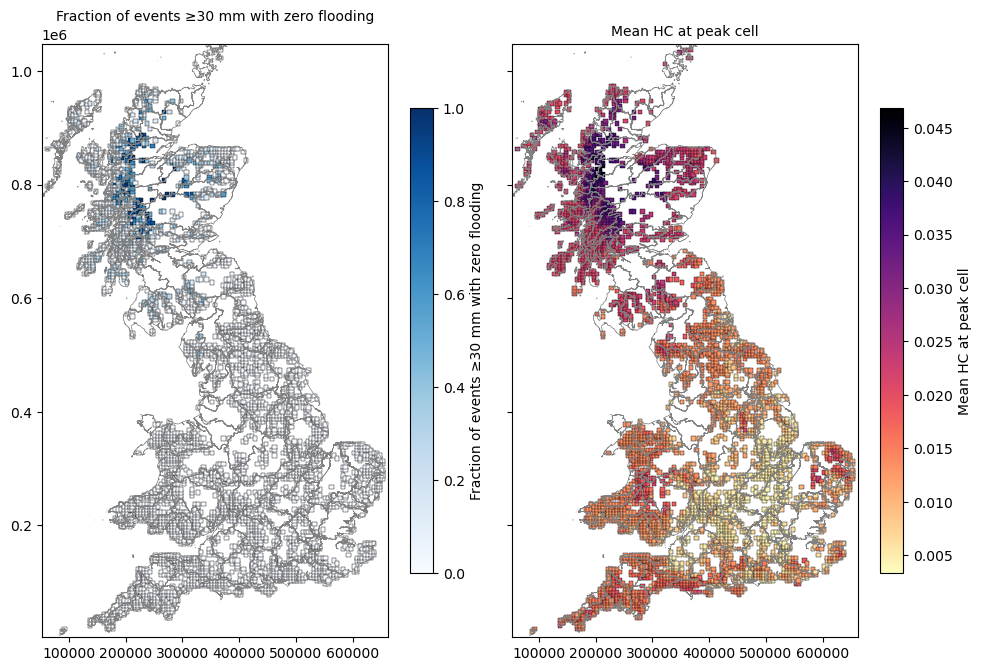

In [19]:
xvar, yvar = "max_precip", "10cm_area"
RAIN_THRESH = 30      # what counts as "lots of rain" (mm), adjust
MIN_WET = 10           # min heavy-rain events per cell to be shown

df = rainfall_events_all_df.dropna(subset=[xvar, yvar]).copy()
wet = df[df[xvar] >= RAIN_THRESH].copy()
wet["is_zero"] = wet[yvar] <= 0

# one row per peak cell (per catchment, in case a cell is the peak for neighbouring catchments)
cell = (wet.groupby(["catchment_num", "x_idx_global", "y_idx_global"])
           .agg(n_wet=("is_zero", "size"),
                n_zero=("is_zero", "sum"),
                x_coord=("x_coord", "first"),
                y_coord=("y_coord", "first"),
               fu=("fu_at_peak_old", "mean"))
           .reset_index())
cell["frac_zero"] = cell["n_zero"] / cell["n_wet"]
cell = cell[cell["n_wet"] >= MIN_WET]
# cell = cell[cell['frac_zero']>0.1]

# --- maps ---
fig, axs = plt.subplots(1, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, col, cmap, label in [
    (axs[0], "frac_zero", "Blues", f"Fraction of events ≥{RAIN_THRESH} mm with zero flooding"),
    (axs[1], "fu",        "magma_r", "Mean HC at peak cell"),]:
    
    CATCHMENTS.boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
    sc = ax.scatter(cell["x_coord"], cell["y_coord"], c=cell[col], cmap=cmap,
                    s=10, marker="s", edgecolor="k", linewidth=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.7, label=label)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=10)

# zoom to where the cells are
pad = 10_000
axs[0].set_xlim(cell["x_coord"].min() - pad, cell["x_coord"].max() + pad)
axs[0].set_ylim(cell["y_coord"].min() - pad, cell["y_coord"].max() + pad)
plt.tight_layout()
plt.show()

In [85]:
cols = ["x_idx_global", "y_idx_global"]

step0 = df0 = rainfall_events_all_df.dropna(subset=cols)
n0 = step0.groupby(cols).size()
print("pixels, all events:          ", len(n0), "| with >50 events:", (n0 > 50).sum())

step1 = step0.dropna(subset=["max_precip", "10cm_area"])
n1 = step1.groupby(cols).size()
print("after dropna on precip/area: ", len(n1), "| with >50 events:", (n1 > 50).sum())

step2 = step1[step1["max_precip"] >= RAIN_THRESH]
n2 = step2.groupby(cols).size()
print(f"after precip >= {RAIN_THRESH}:          ", len(n2), "| with >=3 events:", (n2 >= 3).sum())

print("cells split across catchments:",
      (step0.groupby(cols)["catchment_num"].nunique() > 1).sum())

pixels, all events:           8927 | with >50 events: 168
after dropna on precip/area:  8927 | with >50 events: 168
after precip >= 30:           8927 | with >=3 events: 8064
cells split across catchments: 0


In [86]:
# subset = rainfall_events_all_df

# for i, region in enumerate(np.unique(rainfall_events_all_df['catchment_num'])):
#     print(region)
#     subset = rainfall_events_all_df[
#         rainfall_events_all_df["catchment_num"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])
    
#     # Simple regression: flood area ~ rainfall intensity
#     r2_simple, p_value = find_linear_relationship("max_precip")
#     if r2_simple>0.6:
#         plt.scatter(subset['max_precip'], subset['10cm_area'])
#         plt.show()
# #     # ------------------------
# #     find_linear_relationship_with_max_precip("fu_at_peak_old_mm")    
    
# #     # ------------------------    
# #     find_linear_relationship_with_max_precip("hc_at_peak")    
    
# #     # ------------------------    
# #     find_linear_relationship_with_max_precip("fumax_at_peak") 
    
# #     # ------------------------
# #     find_linear_relationship_with_max_precip("hc_at_peak", "fu_at_peak_old_mm")